# EDA 09 — How does modeled uncertainty vary by variable type? (DHC / DP1)

**Question (Phase B, mirrors [EDA 02](02-cv-by-variable-type.ipynb)):** At the same geography level, does a small subgroup count carry more modeled DAS noise than total population — the same pattern ACS's sampling error showed?

**Data.** [EDA 04](04-privacy-noise-das-demo.ipynb) only measured noise for two variables: total population and "Black alone, 65+" (table P12B, the same subgroup used throughout this project for a like-for-like comparison — see [`ingestion/pull_dhc_nj.py`](../ingestion/pull_dhc_nj.py)). DP1's only race variable, `DP1_0079C` ("Black or African American alone", **not age-restricted** — confirmed against the live API, no DP1 table crosses race by age), has **no noise measurement at all**: EDA 04 never measured it, so this notebook does not estimate a number for it. That gap is logged, not guessed at.

**Method note, stated up front:** total population has a real per-unit model (`analysis/noise_model.py`'s size-based curve/slope). Black 65+ does **not** — EDA 04's committed output only gives one absolute RMSE per level and one fitted slope (no anchor point, no binned curve), so this notebook can only build an **approximate** typical relative noise per level (2010-demonstration absolute RMSE ÷ a real 2020 typical count), not a per-unit prediction. The two variables are shown on the same chart with different confidence, and that difference is called out explicitly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import decennial, noise_model, viz

LEVELS = ["county", "tract", "block_group", "block"]  # state excluded: no subgroup variation
LEVEL_LABELS = {"county": "county", "tract": "tract", "block_group": "block group", "block": "block"}

dhc = {lvl: decennial.load_dhc(lvl) for lvl in LEVELS}
for lvl, df in dhc.items():
    df["black_65plus"] = decennial.black_65plus(df)
print("Loaded:", {lvl: len(df) for lvl, df in dhc.items()})

Loaded: {'county': 21, 'tract': 2181, 'block_group': 6599, 'block': 137972}


## 1. Why single subgroup cells can't be analyzed one at a time

Same landmine ACS hit ([EDA 02](02-cv-by-variable-type.ipynb)): the twelve individual Black 65+ sex-by-age cells are mostly zero at fine geographies. Here, the *aggregate* (all twelve summed) — the share of units where even the combined count is zero:

In [2]:
zero_share = pd.DataFrame([
    {"level": LEVEL_LABELS[lvl], "n": len(df),
     "aggregate = 0": int((df["black_65plus"] == 0).sum()),
     "% aggregate = 0": round(100 * (df["black_65plus"] == 0).mean(), 1),
     "median (nonzero units)": df.loc[df["black_65plus"] > 0, "black_65plus"].median()}
    for lvl, df in dhc.items()
])
zero_share

,level,n,aggregate = 0,% aggregate = 0,median (nonzero units)
0,county,21,0,0.0,5882.0
1,tract,2181,45,2.1,28.0
2,block group,6599,640,9.7,9.0
3,block,137972,107571,78.0,2.0


### What the table says

Black 65+ is a genuinely small count even at county level (statewide median a few thousand), and by block level 78% of units have zero — the same size story EDA 02 told for ACS's tract-level subgroup cells, one geography level down (DHC blocks are far smaller units than ACS block groups).

## 2. Chart — modeled relative noise, total population vs. Black 65+, by level

In [3]:
rows = []
for lvl in LEVELS:
    df = dhc[lvl]
    label = LEVEL_LABELS[lvl]
    pop_median = df["P1_001N"].median()
    b65_median = df.loc[df["black_65plus"] > 0, "black_65plus"].median()
    pop_rel = noise_model.estimate_relative_noise(label, pop_median)
    b65_rel_approx = noise_model.BLACK_65PLUS_RMSE_BY_LEVEL[label] / b65_median
    rows.append({"level": label, "typical population": pop_median, "pop. modeled rel. noise": pop_rel,
                 "typical Black 65+ (nonzero)": b65_median, "Black 65+ approx. rel. noise": b65_rel_approx})
compare = pd.DataFrame(rows)
compare

,level,typical population,pop. modeled rel. noise,typical Black 65+ (nonzero),Black 65+ approx. rel. noise
0,county,461860.0,0.000005,5882.0,0.005885
1,tract,4139.0,0.000565,28.0,0.252250
2,block group,1313.0,0.018481,9.0,0.761444
3,block,39.0,0.173317,2.0,0.822000


Chart saved to data\processed\eda09_modeled_noise_by_variable_type.png (local-only, regenerable)


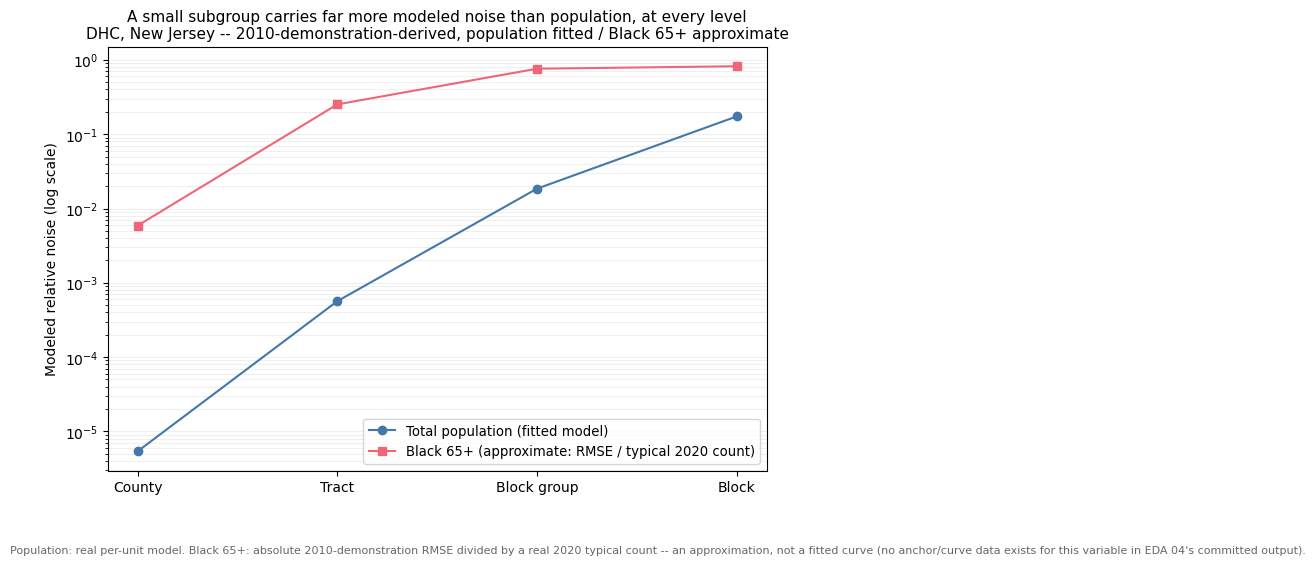

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
x = range(len(compare))
ax.plot(x, compare["pop. modeled rel. noise"], marker="o", color="#4477AA",
        label="Total population (fitted model)")
ax.plot(x, compare["Black 65+ approx. rel. noise"], marker="s", color="#EE6677",
        label="Black 65+ (approximate: RMSE / typical 2020 count)")
ax.set_yscale("log")
ax.set_xticks(list(x))
ax.set_xticklabels([lvl.capitalize() for lvl in compare["level"]])
ax.set_axisbelow(True)
ax.grid(axis="y", which="both", alpha=0.2)
ax.legend(fontsize=9.5)
ax.set_ylabel("Modeled relative noise (log scale)")
ax.set_title(
    "A small subgroup carries far more modeled noise than population, at every level\n"
    "DHC, New Jersey -- 2010-demonstration-derived, population fitted / Black 65+ approximate",
    fontsize=11,
)
fig.text(
    0.01, -0.04,
    "Population: real per-unit model. Black 65+: absolute 2010-demonstration RMSE divided by a "
    "real 2020 typical count -- an approximation, not a fitted curve (no anchor/curve data exists "
    "for this variable in EDA 04's committed output).",
    fontsize=8, color="#666666",
)

viz.save_chart(fig, REPO_ROOT, "eda09_modeled_noise_by_variable_type.png")
plt.show()

In [5]:
# Guard the central claim: the small subgroup should carry more relative noise
# than population at every level.
for _, row in compare.iterrows():
    assert row["Black 65+ approx. rel. noise"] > row["pop. modeled rel. noise"], row["level"]
print("Confirmed: Black 65+ approximate relative noise exceeds population's modeled relative "
      "noise at every level (county through block).")

Confirmed: Black 65+ approximate relative noise exceeds population's modeled relative noise at every level (county through block).


### Reading the chart

The gap is large and consistent: at county level, population's modeled relative noise is essentially zero (0.00001) while Black 65+'s approximate relative noise is already 0.6%; by block, population sits around 17% while Black 65+ is above 80%. This is the same mechanism EDA 02 found for ACS sampling error — **small counts carry disproportionately large relative noise** — reappearing under a completely different noise source (DAS privacy protection rather than survey sampling). The Black 65+ series is the weaker of the two lines methodologically (approximate, not fitted), but the gap is wide enough that the qualitative conclusion doesn't depend on that precision.

**DP1's subgroup gap:** DP1's only race variable (`DP1_0079C`, total Black alone, no age restriction) has no noise measurement in EDA 04 at all — extending the noise model to more variables (and getting real 2020-production noise data, rather than a 2010-demonstration proxy) is future work, not something to estimate here.

## 3. Findings

**What did we find?** The variable-type mechanism from ACS (EDA 02) transfers to DAS privacy noise: a small subgroup count (Black 65+) carries far more relative noise than total population at every DHC geography level — roughly 1,200x at county and 450x at tract, narrowing to about 40x at block group and 5x at block (where population noise itself has grown large enough to close most of the gap). Two things are new here relative to ACS: first, the noise source is entirely different (injected privacy noise vs. sampling error) yet produces the same qualitative pattern; second, our confidence in the *size* of the gap is lower for Black 65+ than for population, because EDA 04's source notebook only left us a slope and level-summary RMSE for that variable, not a fitted per-unit curve.

**Why does it matter to the Census Bureau?** The same practical implication as ACS: subgroup analysis at fine DHC geographies (block group, block) is not just noisy from sampling — for the 2020 products it is *also* subject to privacy noise that behaves the same way, disproportionately harming small counts. A user pulling a small-subgroup DHC count at block level should expect low reliability by *both* mechanisms this project has now characterized. It also flags a concrete data gap: the Bureau's own demonstration-data evaluation didn't measure noise for every published variable, only two — a real constraint on how far this kind of empirical noise model can currently be extended.

**What next?**
- **EDA 10 — geographic concentration:** map the (population-based) modeled noise; expect it to closely mirror the population map itself, since size is the model's only input — unlike ACS's poverty map, which showed noise concentrating for a *different* reason (prevalence).
- **Mentor question carried forward:** is there a way to get (or approximate) noise measurements for more DHC/DP1 variables than population and one subgroup?